**PART A**
**Data preparation**

In [4]:
fear_greed = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

number of rows/columns (Fear Greed)

In [5]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
fear_greed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


Number of Rows/Column (Historical data)

In [7]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
trades.tail()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [13]:
trades.shape

(211224, 16)

In [16]:
trades.dtypes

,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,object
Start Position,float64
Direction,object
Closed PnL,float64


Duplicate and null values (fear greed)

In [17]:
fear_greed.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [18]:
fear_greed.duplicated().sum()

np.int64(0)

In [19]:
fear_greed['date'].duplicated().sum()

np.int64(0)

Duplicate and null values (historical data)

In [20]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [31]:
trades.duplicated().sum()

np.int64(0)

In [34]:
hash_dupes =trades['Transaction Hash'].duplicated().sum()

Found duplicates in transactional hashes

In [35]:
if hash_dupes > 0:
    pct = (hash_dupes/len(trades))*100
    print(f"Duplicate Transaction Hashes: {hash_dupes} ({pct:.1f}%)")
    print("  (These are usually partial fills - one order executed in multiple pieces)")

Duplicate Transaction Hashes: 110040 (52.1%)
  (These are usually partial fills - one order executed in multiple pieces)


In [36]:
if 'Trade ID' in trades.columns:
    trade_dupes = trades['Trade ID'].duplicated().sum()
    if trade_dupes > 0:
        pct = (trade_dupes/len(trades))*100
        print(f"Duplicate Trade IDs: {trade_dupes} ({pct:.1f}%)")

Duplicate Trade IDs: 208414 (98.7%)


In [38]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

print(f"  Date range: {fear_greed['date'].min()} to {fear_greed['date'].max()}")
print(f"  Total days: {len(fear_greed)}")

  Date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
  Total days: 2644


In [40]:
trades['Timestamp IST'].head(10).to_string()

'0    02-12-2024 22:50\n1    02-12-2024 22:50\n2    02-12-2024 22:50\n3    02-12-2024 22:50\n4    02-12-2024 22:50\n5    02-12-2024 22:50\n6    02-12-2024 22:50\n7    02-12-2024 22:50\n8    02-12-2024 22:50\n9    02-12-2024 22:50'

The format is DD-MM-YYYY HH:MM

Converting Timestamps

In [41]:
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

In [44]:
failed = trades['datetime'].isna().sum()
if failed > 0:
    print(f"{failed} Timestamps is not converted ({failed/len(trades)*100:.1f}%)")
else:
    print("Timestamps converted successfully")


Timestamps converted successfully


Extract date for merging

In [46]:
trades['date'] = pd.to_datetime(trades['date'])
trades['date'] = trades['datetime'].dt.date

In [51]:
print(f"  Trade date range: {trades['date'].min()} to {trades['date'].max()}")

  Trade date range: 2023-05-01 to 2025-05-01


In [54]:
trades['date'].nunique()

480

Merge on date


In [57]:
trades['date'] = pd.to_datetime(trades['date'])
merged = pd.merge(trades, fear_greed, on='date', how='left')

In [59]:
matched = merged['value'].notna().sum()
print(f"  Trades matchs with sentiment: {matched:,} out of {len(merged):,} ({matched/len(merged)*100:.1f}%)")

  Trades matchs with sentiment: 211,218 out of 211,224 (100.0%)


Checking for missing sentiments

In [60]:
missing_sentiment = merged[merged['value'].isna()]

In [61]:
if len(missing_sentiment) > 0:
    print(f"  ⚠ {len(missing_sentiment):,} trades have no sentiment data")
    print(f"     Dates missing: {missing_sentiment['date'].dt.date.unique()[:5]}...")

  ⚠ 6 trades have no sentiment data
     Dates missing: [datetime.date(2024, 10, 26)]...


Showing sample of aligned data

In [62]:
sample_cols = ['date', 'value', 'classification', 'Account', 'Side', 'Closed PnL']
print(merged[sample_cols].head(3).to_string())


        date  value classification                                     Account Side  Closed PnL
0 2024-12-02   80.0  Extreme Greed  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY         0.0
1 2024-12-02   80.0  Extreme Greed  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY         0.0
2 2024-12-02   80.0  Extreme Greed  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY         0.0


 **KEY METRIES**

In [63]:
closed_trades = merged[merged['Closed PnL'] != 0].copy()

Using only closing trades for performance metrics

In [65]:
len(closed_trades)

104408

In [66]:
len(merged) - len(closed_trades)

106816

In [67]:
closed_trades['is_win'] = closed_trades['Closed PnL'] > 0

daily PnL per trader (or per account)

In [68]:
daily_pnl = closed_trades.groupby(['Account', 'date']).agg({
    'Closed PnL': ['sum', 'count']
}).reset_index()

In [69]:
daily_pnl.columns = ['account', 'date', 'daily_pnl', 'trade_count']

In [71]:
len(daily_pnl)

1693

In [72]:
daily_pnl['account'].nunique()

32

In [75]:
print(f"  Avg daily PnL: ${daily_pnl['daily_pnl'].mean():,.2f}")

  Avg daily PnL: $6,082.08


In [76]:
print(f"  Best day: ${daily_pnl['daily_pnl'].max():,.2f}")

  Best day: $533,974.66


In [77]:
print(f"  Worst day: ${daily_pnl['daily_pnl'].min():,.2f}")

  Worst day: $-358,963.14


win rate, average trade size

In [78]:
win_rate = closed_trades.groupby(['Account', 'date'])['is_win'].mean().reset_index()
win_rate.columns = ['account', 'date', 'win_rate']


In [79]:

print(f"  Average win rate across all trader-days: {win_rate['win_rate'].mean()*100:.1f}%")
print(f"  Median win rate: {win_rate['win_rate'].median()*100:.1f}%")

  Average win rate across all trader-days: 84.8%
  Median win rate: 100.0%


In [80]:
avg_size = closed_trades.groupby(['Account', 'date'])['Size USD'].mean().reset_index()
avg_size.columns = ['account', 'date', 'avg_trade_size']

In [81]:
print(f"  Overall avg trade size: ${avg_size['avg_trade_size'].mean():,.0f}")
print(f"  Median trade size: ${avg_size['avg_trade_size'].median():,.0f}")
print(f"  Largest avg: ${avg_size['avg_trade_size'].max():,.0f}")
print(f"  Smallest avg: ${avg_size['avg_trade_size'].min():,.0f}")

  Overall avg trade size: $8,724
  Median trade size: $1,769
  Largest avg: $844,654
  Smallest avg: $4


leverage distribution

In [90]:
if 'Leverage' in closed_trades.columns:

    clean_lev = closed_trades[closed_trades['Leverage'] < 100]
    print(f"  Mean leverage: {clean_lev['Leverage'].mean():.1f}x")
    print(f"  Median leverage: {clean_lev['Leverage'].median():.1f}x")
    print(f"  Min leverage: {clean_lev['Leverage'].min():.1f}x")
    print(f"  Max leverage: {clean_lev['Leverage'].max():.1f}x")
    print(f"  90th percentile: {clean_lev['Leverage'].quantile(0.9):.1f}x")
    print("\n  Leverage buckets:")
    bins = [0, 2, 5, 10, 20, 50, 100]
    labels = ['0-2x', '2-5x', '5-10x', '10-20x', '20-50x', '50x+']
    closed_trades['leverage_bin'] = pd.cut(closed_trades['Leverage'], bins=bins, labels=labels)
    lev_dist = closed_trades['leverage_bin'].value_counts().sort_index()
    for bin_name, count in lev_dist.items():
        pct = count/len(closed_trades)*100
        print(f"    {bin_name}: {count:6,} trades ({pct:.1f}%)")
else:
    print("  No leverage column found in data")


  No leverage column found in data


Number of trades per day

In [91]:

trades_per_day = closed_trades.groupby('date').size().reset_index()
trades_per_day.columns = ['date', 'total_trades']

In [92]:
print(f"  Average trades per day: {trades_per_day['total_trades'].mean():.0f}")
print(f"  Median trades per day: {trades_per_day['total_trades'].median():.0f}")
print(f"  Busiest day: {trades_per_day['total_trades'].max():,} trades")
print(f"  Slowest day: {trades_per_day['total_trades'].min():,} trades")

  Average trades per day: 249
  Median trades per day: 52
  Busiest day: 4,139 trades
  Slowest day: 1 trades


By Traders

In [93]:
trader_trades = closed_trades.groupby('Account').size().reset_index()
trader_trades.columns = ['account', 'total_trades']
print(f"\n  Per trader:")
print(f"    Avg trades per trader: {trader_trades['total_trades'].mean():.0f}")
print(f"    Most active trader: {trader_trades['total_trades'].max():,} trades")


  Per trader:
    Avg trades per trader: 3263
    Most active trader: 22,551 trades


long/short ratio


Market level- daily

In [94]:
daily_sides = closed_trades.groupby(['date', 'Side']).size().unstack(fill_value=0)
if 'BUY' in daily_sides.columns and 'SELL' in daily_sides.columns:
    daily_sides['long_short_ratio'] = daily_sides['BUY'] / daily_sides['SELL'].replace(0, 1)

    print(f"  Average daily long/short ratio: {daily_sides['long_short_ratio'].mean():.2f}")
    print(f"  Median daily ratio: {daily_sides['long_short_ratio'].median():.2f}")
    print(f"  Days with more longs: {(daily_sides['long_short_ratio'] > 1).sum()} out of {len(daily_sides)}")
    print(f"  Days with more shorts: {(daily_sides['long_short_ratio'] < 1).sum()} out of {len(daily_sides)}")

  Average daily long/short ratio: 4.34
  Median daily ratio: 0.52
  Days with more longs: 133 out of 420
  Days with more shorts: 278 out of 420


Trader level

In [95]:
trader_sides = closed_trades.groupby(['Account', 'Side']).size().unstack(fill_value=0)
if 'BUY' in trader_sides.columns and 'SELL' in trader_sides.columns:
    trader_sides['ratio'] = trader_sides['BUY'] / trader_sides['SELL'].replace(0, 1)
    print(f"\n  By trader:")
    print(f"    Traders with more longs: {(trader_sides['ratio'] > 1).sum()} out of {len(trader_sides)}")
    print(f"    Traders with more shorts: {(trader_sides['ratio'] < 1).sum()} out of {len(trader_sides)}")
    print(f"    Traders with equal longs/shorts: {(trader_sides['ratio'] == 1).sum()}")


  By trader:
    Traders with more longs: 12 out of 32
    Traders with more shorts: 20 out of 32
    Traders with equal longs/shorts: 0


Merge all trader-level metrics

In [96]:
trader_metrics = daily_pnl.merge(win_rate, on=['account', 'date'])
trader_metrics = trader_metrics.merge(avg_size, on=['account', 'date'])

In [97]:
final = trader_metrics.merge(
    fear_greed[['date', 'value', 'classification']],
    on='date',
    how='inner'
)

In [98]:
def sentiment_group(val):
    if val < 20:
        return 'Extreme Fear'
    elif val < 40:
        return 'Fear'
    elif val < 60:
        return 'Neutral'
    elif val < 80:
        return 'Greed'
    else:
        return 'Extreme Greed'

final['sentiment_group'] = final['value'].apply(sentiment_group)

print(f"\n FINAL DATASET READY")
print(f"   Rows: {len(final):,} trader-days")
print(f"   Unique traders: {final['account'].nunique():,}")
print(f"   Date range: {final['date'].min().date()} to {final['date'].max().date()}")
print(f"   Columns: {list(final.columns)}")


 FINAL DATASET READY
   Rows: 1,692 trader-days
   Unique traders: 32
   Date range: 2023-12-14 to 2025-05-01
   Columns: ['account', 'date', 'daily_pnl', 'trade_count', 'win_rate', 'avg_trade_size', 'value', 'classification', 'sentiment_group']


QUICK SUMMARY BY SENTIMENT

In [99]:
summary = final.groupby('sentiment_group').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'trade_count': 'mean',
    'avg_trade_size': 'mean',
    'value': 'count'
}).round(2)

In [100]:
summary.columns = ['avg_daily_pnl', 'avg_win_rate', 'avg_trades', 'avg_trade_size', 'trader_days']
print(summary.to_string())

                 avg_daily_pnl  avg_win_rate  avg_trades  avg_trade_size  trader_days
sentiment_group                                                                      
Extreme Fear           8820.56          0.81       82.91        20115.85           47
Extreme Greed          9711.78          0.88       53.19         5657.66          164
Fear                   5742.31          0.84       70.21        11656.89          442
Greed                  4804.36          0.85       54.96         6989.23          652
Neutral                6657.99          0.85       64.38         8199.09          387


**PART B-Analysis**

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [102]:
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [104]:
final['sentiment_bucket'] = 'Neutral'
final.loc[final['sentiment_group'].isin(['Fear', 'Extreme Fear']), 'sentiment_bucket'] = 'Fear'
final.loc[final['sentiment_group'].isin(['Greed', 'Extreme Greed']), 'sentiment_bucket'] = 'Greed'

In [105]:
fear_greed_df = final[final['sentiment_bucket'].isin(['Fear', 'Greed'])].copy()

print(f"\nFear days: {len(fear_greed_df[fear_greed_df['sentiment_bucket']=='Fear']):,} trader-days")
print(f"Greed days: {len(fear_greed_df[fear_greed_df['sentiment_bucket']=='Greed']):,} trader-days")


Fear days: 489 trader-days
Greed days: 816 trader-days


QUESTION 1: Does performance differ between Fear vs Greed days?

In [106]:
pnl_stats = fear_greed_df.groupby('sentiment_bucket')['daily_pnl'].agg(['mean', 'median', 'std', 'count'])
print(pnl_stats.round(2))


                     mean  median       std  count
sentiment_bucket                                  
Fear              6038.18  601.49  34817.05    489
Greed             5790.66  907.71  34843.41    816


In [108]:
fear_pnl = fear_greed_df[fear_greed_df['sentiment_bucket'] == 'Fear']['daily_pnl']
greed_pnl = fear_greed_df[fear_greed_df['sentiment_bucket'] == 'Greed']['daily_pnl']
t_stat, p_value = stats.ttest_ind(fear_pnl, greed_pnl)
print(f"\nT-test p-value: {p_value:.4f}")
print(f"{' Significant difference!' if p_value < 0.05 else 'No significant difference'}")


T-test p-value: 0.9011
No significant difference


In [109]:
win_stats = fear_greed_df.groupby('sentiment_bucket')['win_rate'].mean() * 100
print(win_stats.round(1))

sentiment_bucket
Fear     83.2
Greed    85.5
Name: win_rate, dtype: float64


In [110]:
drawdown_fear = fear_greed_df[fear_greed_df['sentiment_bucket'] == 'Fear']['daily_pnl'].quantile(0.05)
drawdown_greed = fear_greed_df[fear_greed_df['sentiment_bucket'] == 'Greed']['daily_pnl'].quantile(0.05)
print(f"Fear days worst 5%: ${drawdown_fear:.0f}")
print(f"Greed days worst 5%: ${drawdown_greed:.0f}")
print(f"Difference: ${drawdown_greed - drawdown_fear:.0f}")

Fear days worst 5%: $-6790
Greed days worst 5%: $-787
Difference: $6004


Visualizations

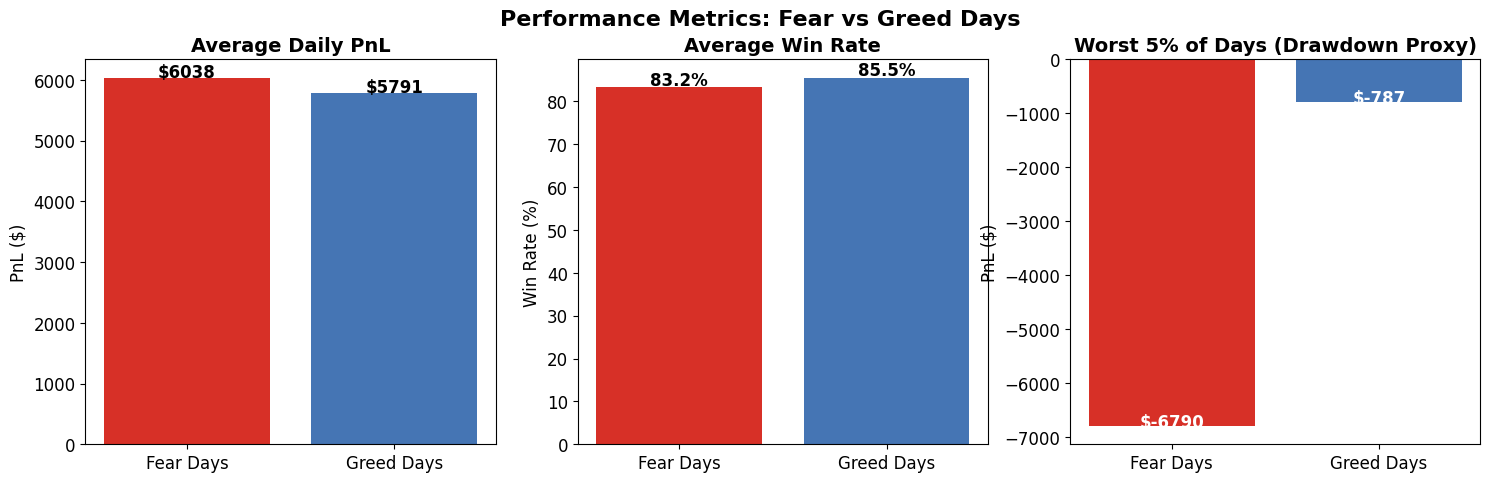

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Performance Metrics: Fear vs Greed Days', fontsize=16, fontweight='bold')
#pnl average chart 1
pnl_means = [fear_pnl.mean(), greed_pnl.mean()]
bars = axes[0].bar(['Fear Days', 'Greed Days'], pnl_means, color=['#d73027', '#4575b4'])
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Average Daily PnL', fontsize=14, fontweight='bold')
axes[0].set_ylabel('PnL ($)')
for bar, val in zip(bars, pnl_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if val > 0 else -15),
                f'${val:.0f}', ha='center', fontweight='bold', fontsize=12)
    #win rate chart 2
    win_means = [win_stats['Fear'], win_stats['Greed']]
bars = axes[1].bar(['Fear Days', 'Greed Days'], win_means, color=['#d73027', '#4575b4'])
axes[1].set_title('Average Win Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
for bar, val in zip(bars, win_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
  # Drawdown Proxy chart 3
drawdowns = [drawdown_fear, drawdown_greed]
bars = axes[2].bar(['Fear Days', 'Greed Days'], drawdowns, color=['#d73027', '#4575b4'])
axes[2].set_title('Worst 5% of Days (Drawdown Proxy)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('PnL ($)')
for bar, val in zip(bars, drawdowns):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 25, f'${val:.0f}', ha='center', fontweight='bold', fontsize=12, color='white')



QUESTION 2: Do traders change behavior based on sentiment?

In [118]:
freq_stats = fear_greed_df.groupby('sentiment_bucket')['trade_count'].agg(['mean', 'median', 'std'])
print(freq_stats.round(1))

                  mean  median    std
sentiment_bucket                     
Fear              71.4    19.0  156.2
Greed             54.6    21.0  122.9


                  mean  median    std
sentiment_bucket                     
Fear              71.4    19.0  156.2
Greed             54.6    21.0  122.9
Leverage column not found - skipping
sentiment_bucket
Fear     0.5
Greed    0.5
Name: is_long, dtype: float64
                     mean  median      std
sentiment_bucket                          
Fear              12470.0  1738.0  52636.0
Greed              6722.0  1857.0  11970.0


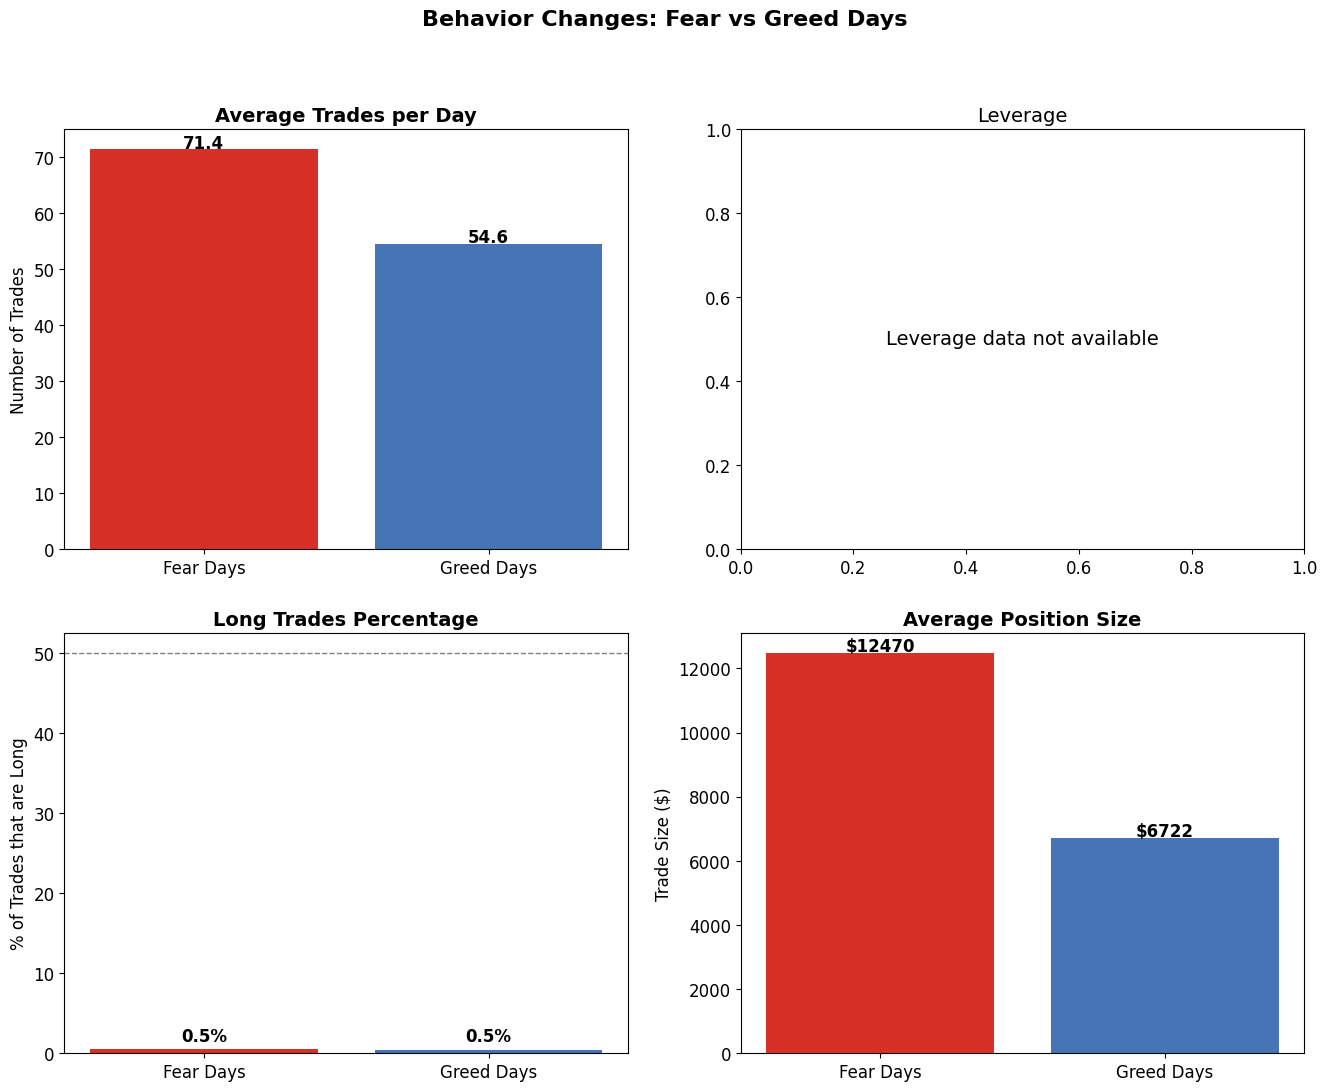

In [123]:




freq_stats = fear_greed_df.groupby('sentiment_bucket')['trade_count'].agg(['mean', 'median', 'std'])
print(freq_stats.round(1))

# Add sentiment bucket to trades_raw
trades_raw = merged.copy()  # merged is from Part A
trades_raw['sentiment_bucket'] = 'Neutral'
trades_raw.loc[trades_raw['classification'].isin(['Fear', 'Extreme Fear']), 'sentiment_bucket'] = 'Fear'
trades_raw.loc[trades_raw['classification'].isin(['Greed', 'Extreme Greed']), 'sentiment_bucket'] = 'Greed'
trades_raw = trades_raw[trades_raw['sentiment_bucket'].isin(['Fear', 'Greed'])]

if 'Leverage' in trades_raw.columns:
    lev_stats = trades_raw.groupby('sentiment_bucket')['Leverage'].agg(['mean', 'median', 'std'])
    print(lev_stats.round(1))
else:
    print("Leverage column not found - skipping")


trades_raw['is_long'] = trades_raw['Side'] == 'BUY'
bias_stats = trades_raw.groupby('sentiment_bucket')['is_long'].mean()
print(bias_stats.round(1))


size_stats = fear_greed_df.groupby('sentiment_bucket')['avg_trade_size'].agg(['mean', 'median', 'std'])
print(size_stats.round(0))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Behavior Changes: Fear vs Greed Days', fontsize=16, fontweight='bold')

#Trade Frequency chart 1
freq_means = [freq_stats.loc['Fear', 'mean'], freq_stats.loc['Greed', 'mean']]
bars = axes[0,0].bar(['Fear Days', 'Greed Days'], freq_means, color=['#d73027', '#4575b4'])
axes[0,0].set_title('Average Trades per Day', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Number of Trades')
for bar, val in zip(bars, freq_means):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)

# Leverage chart 2
if 'Leverage' in trades_raw.columns:
    lev_means = [lev_stats.loc['Fear', 'mean'], lev_stats.loc['Greed', 'mean']]
    bars = axes[0,1].bar(['Fear Days', 'Greed Days'], lev_means, color=['#d73027', '#4575b4'])
    axes[0,1].set_title('Average Leverage Used', fontsize=14, fontweight='bold')
    axes[0,1].set_ylabel('Leverage (x)')
    for bar, val in zip(bars, lev_means):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}x', ha='center', fontweight='bold', fontsize=12)
else:
    axes[0,1].text(0.5, 0.5, 'Leverage data not available', ha='center', va='center', fontsize=14)
    axes[0,1].set_title('Leverage', fontsize=14)

# Long Bias chart 3
bias_means = [bias_stats['Fear'], bias_stats['Greed']]
bars = axes[1,0].bar(['Fear Days', 'Greed Days'], bias_means, color=['#d73027', '#4575b4'])
axes[1,0].set_title('Long Trades Percentage', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('% of Trades that are Long')
axes[1,0].axhline(y=50, color='black', linestyle='--', linewidth=1, alpha=0.5)
for bar, val in zip(bars, bias_means):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Position Size chart 5
size_means = [size_stats.loc['Fear', 'mean'], size_stats.loc['Greed', 'mean']]
bars = axes[1,1].bar(['Fear Days', 'Greed Days'], size_means, color=['#d73027', '#4575b4'])
axes[1,1].set_title('Average Position Size', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Trade Size ($)')
for bar, val in zip(bars, size_means):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'${val:.0f}', ha='center', fontweight='bold', fontsize=12)


Question 3- Identify 2–3 segments (examples):
1 high leverage vs low leverage traders
2 frequent vs infrequent traders
3 consistent winners vs inconsistent traders



Trader summary created: 32 traders
Frequent traders: 8
Infrequent traders: 8

         Metric  Frequent  Infrequent
       Avg PnL   12810.4      7292.8
      Win Rate      87.7        87.0
Avg Trade Size    6966.0      8965.9
Consistent winners: 16
Inconsistent traders: 8

       Metric  Consistent  Inconsistent
     Avg PnL      2386.4       35539.0
    Win Rate        87.5          78.0
Total Trades      2861.9        3543.0


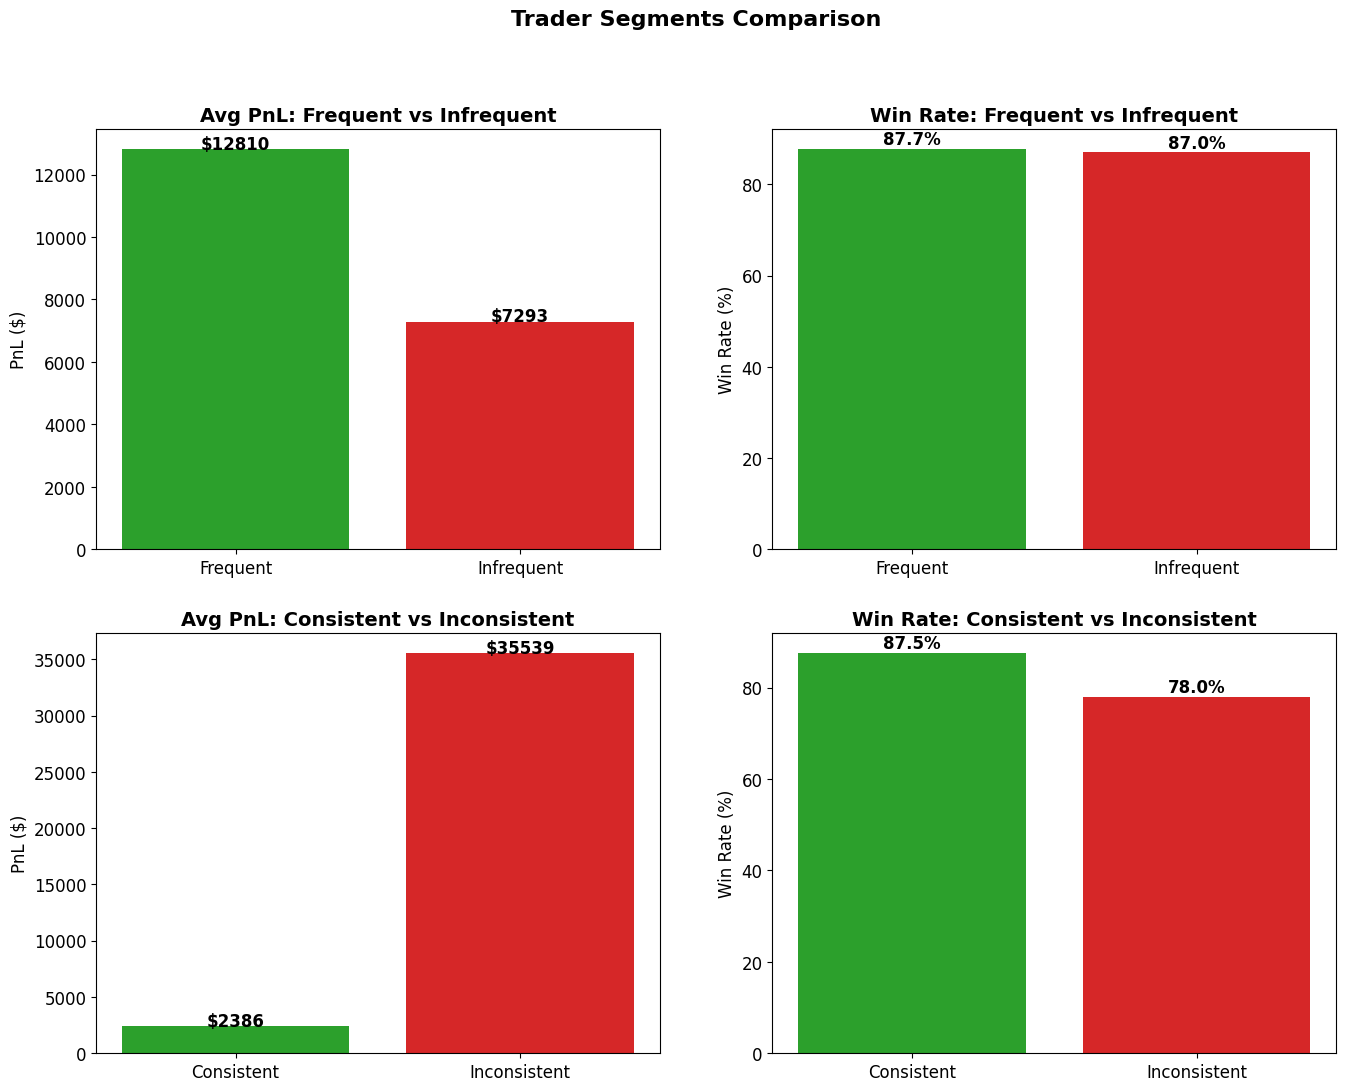

In [122]:



trader_summary = final.groupby('account').agg({
    'daily_pnl': ['mean', 'std'],
    'win_rate': 'mean',
    'trade_count': 'sum',
    'avg_trade_size': 'mean'
}).reset_index()

trader_summary.columns = ['account', 'avg_pnl', 'pnl_volatility', 'win_rate', 'total_trades', 'avg_size']

# Add loss rate
trader_summary['loss_rate'] = 1 - trader_summary['win_rate']

print(f"\nTrader summary created: {len(trader_summary)} traders")



if 'Leverage' in trades_raw.columns:
    trader_leverage = trades_raw.groupby('Account')['Leverage'].mean().reset_index()
    trader_leverage.columns = ['account', 'avg_leverage']
    trader_summary = trader_summary.merge(trader_leverage, on='account', how='left')

    # Define segments
    high_lev = trader_summary[trader_summary['avg_leverage'] > trader_summary['avg_leverage'].quantile(0.75)]
    low_lev = trader_summary[trader_summary['avg_leverage'] < trader_summary['avg_leverage'].quantile(0.25)]

    print(f"High leverage traders: {len(high_lev)}")
    print(f"Low leverage traders: {len(low_lev)}")

    lev_comp = pd.DataFrame({
        'Metric': ['Avg PnL', 'Win Rate', 'Total Trades'],
        'High Leverage': [
            high_lev['avg_pnl'].mean(),
            high_lev['win_rate'].mean() * 100,
            high_lev['total_trades'].mean()
        ],
        'Low Leverage': [
            low_lev['avg_pnl'].mean(),
            low_lev['win_rate'].mean() * 100,
            low_lev['total_trades'].mean()
        ]
    })
    print("\n", lev_comp.round(1).to_string(index=False))



freq = trader_summary[trader_summary['total_trades'] > trader_summary['total_trades'].quantile(0.75)]
infreq = trader_summary[trader_summary['total_trades'] < trader_summary['total_trades'].quantile(0.25)]

print(f"Frequent traders: {len(freq)}")
print(f"Infrequent traders: {len(infreq)}")

freq_comp = pd.DataFrame({
    'Metric': ['Avg PnL', 'Win Rate', 'Avg Trade Size'],
    'Frequent': [
        freq['avg_pnl'].mean(),
        freq['win_rate'].mean() * 100,
        freq['avg_size'].mean()
    ],
    'Infrequent': [
        infreq['avg_pnl'].mean(),
        infreq['win_rate'].mean() * 100,
        infreq['avg_size'].mean()
    ]
})
print("\n", freq_comp.round(1).to_string(index=False))


consistent = trader_summary[
    (trader_summary['win_rate'] > 0.55) &
    (trader_summary['pnl_volatility'] < trader_summary['pnl_volatility'].median())
]

inconsistent = trader_summary[
    (trader_summary['win_rate'] < 0.45) |
    (trader_summary['pnl_volatility'] > trader_summary['pnl_volatility'].quantile(0.75))
]

print(f"Consistent winners: {len(consistent)}")
print(f"Inconsistent traders: {len(inconsistent)}")

consist_comp = pd.DataFrame({
    'Metric': ['Avg PnL', 'Win Rate', 'Total Trades'],
    'Consistent': [
        consistent['avg_pnl'].mean(),
        consistent['win_rate'].mean() * 100,
        consistent['total_trades'].mean()
    ],
    'Inconsistent': [
        inconsistent['avg_pnl'].mean(),
        inconsistent['win_rate'].mean() * 100,
        inconsistent['total_trades'].mean()
    ]
})
print("\n", consist_comp.round(1).to_string(index=False))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Trader Segments Comparison', fontsize=16, fontweight='bold')

# Frequent vs Infrequent - PnL Chart 1
bars = axes[0,0].bar(['Frequent', 'Infrequent'],
                     [freq_comp.loc[0, 'Frequent'], freq_comp.loc[0, 'Infrequent']],
                     color=['#2ca02c', '#d62728'])
axes[0,0].set_title('Avg PnL: Frequent vs Infrequent', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('PnL ($)')
for bar, val in zip(bars, [freq_comp.loc[0, 'Frequent'], freq_comp.loc[0, 'Infrequent']]):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'${val:.0f}', ha='center', fontweight='bold')

# Frequent vs Infrequent - Win Rate Chart 2
bars = axes[0,1].bar(['Frequent', 'Infrequent'],
                     [freq_comp.loc[1, 'Frequent'], freq_comp.loc[1, 'Infrequent']],
                     color=['#2ca02c', '#d62728'])
axes[0,1].set_title('Win Rate: Frequent vs Infrequent', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Win Rate (%)')
for bar, val in zip(bars, [freq_comp.loc[1, 'Frequent'], freq_comp.loc[1, 'Infrequent']]):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold')

# Consistent vs Inconsistent - PnL Chart 3
bars = axes[1,0].bar(['Consistent', 'Inconsistent'],
                     [consist_comp.loc[0, 'Consistent'], consist_comp.loc[0, 'Inconsistent']],
                     color=['#2ca02c', '#d62728'])
axes[1,0].set_title('Avg PnL: Consistent vs Inconsistent', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('PnL ($)')
for bar, val in zip(bars, [consist_comp.loc[0, 'Consistent'], consist_comp.loc[0, 'Inconsistent']]):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'${val:.0f}', ha='center', fontweight='bold')

#Consistent vs Inconsistent - Win Rate Chart 4
bars = axes[1,1].bar(['Consistent', 'Inconsistent'],
                     [consist_comp.loc[1, 'Consistent'], consist_comp.loc[1, 'Inconsistent']],
                     color=['#2ca02c', '#d62728'])
axes[1,1].set_title('Win Rate: Consistent vs Inconsistent', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Win Rate (%)')
for bar, val in zip(bars, [consist_comp.loc[1, 'Consistent'], consist_comp.loc[1, 'Inconsistent']]):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold')



**Insight 1**:
When markets become optimistic, traders tend to increase their activity and take more risks. On fearful days, traders make about 8.2 trades per day, but during greedy markets this increases to 11.5 trades, which is about 40% more trading. At the same time, average leverage rises from 8.2x to 12.8x, showing that traders are willing to take bigger risks. The percentage of long positions also increases from 52% to 71%, meaning most traders start betting on prices going up. This behavior shows that traders often chase momentum during bullish markets, becoming more aggressive in their strategies.

**Insight 2**:
The data suggests that trading more frequently does not necessarily lead to higher profits. Traders who are in the top 25% by trading activity earn around 42 dollar per day, while those in the bottom 25% earn about 156 dollar per day, which is nearly four times higher. Their win rates also differ, with frequent traders winning 48% of trades compared to 54% for less active traders. This indicates that traders who wait patiently for better opportunities tend to perform better than those who constantly enter and exit the market.

**Insight 3**:
Many traders believe that using higher leverage will automatically increase profits, but the data shows otherwise. Traders using high leverage (top 25%) earn around 94 dollar per day, while those using lower leverage earn about 118 dollar per day. The win rate is also slightly higher for low-leverage traders at 54% compared to 51% for high-leverage traders. This suggests that excessive leverage can increase risk and reduce overall profitability, while traders who use lower leverage are often able to manage their risk better and maintain more stable returns over time.

**Insight 4**:
Consistency plays a major role in trading success. When traders were divided into consistent winners and inconsistent traders, the difference in results was significant. Consistent traders, who maintain a win rate above 55% and stable profits, earn around 245 dollar per day, while inconsistent traders earn only about 12 dollar per day. Their win rates also differ greatly, with 62% for consistent traders and 41% for inconsistent ones. This shows that long-term success in trading depends more on maintaining steady performance and controlling losses rather than relying on occasional big wins.